In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub
import re
import nltk
import numpy as np
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import string
import spacy
from spacy.lang.en.stop_words import STOP_WORDS
from string import punctuation
from heapq import nlargest
from sklearn.linear_model import LogisticRegression
from tensorflow.keras.models import Sequential, Model, load_model
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, Input, Embedding, SpatialDropout1D, Conv1D, GlobalMaxPooling1D, Flatten, BatchNormalization, Dropout
import seaborn as sns
from tensorflow.keras.preprocessing.text import text_to_word_sequence, Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, TensorBoard
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import roc_auc_score, log_loss, classification_report, confusion_matrix, accuracy_score, mean_squared_error, ConfusionMatrixDisplay
from tensorflow.keras.utils import plot_model
import wordcloud
import os
import requests
import zipfile
import pickle

### 1. Load in the data and analyze each column.

In [ ]:
# Download latest version
path = kagglehub.dataset_download("zulkarnainsaurav/imdb-multimodal-vision-and-nlp-genre-classification")

print("Path to dataset files:", path)

100%|██████████| 56.1M/56.1M [00:04<00:00, 13.8MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/zulkarnainsaurav/imdb-multimodal-vision-and-nlp-genre-classification/versions/1


/root/.cache/kagglehub/datasets/zulkarnainsaurav/imdb-multimodal-vision-and-nlp-genre-classification/versions/1/IMDB_four_genre_larger_plot_description.csv

### EDA

In [ ]:
df = pd.read_csv(path + "/IMDB_four_genre_larger_plot_description.csv")
df.head()

,movie_id,description,genre
0,tt12783454,Elle Evans (Joey King) has finally completed h...,romance
1,tt1798632,A young girl tries to understand how she myste...,horror
2,tt9214832,"In 1800s England, a well meaning but selfish y...",comedy
3,tt8522006,Abby Holland (Kristen Stewart) and Harper Cald...,romance
4,tt21249656,Olga and Maks are 15 years apart. She is a suc...,romance


In [ ]:
print(df.shape)

(1000, 3)


In [ ]:
df[df['movie_id'] == "tt14913250"]

,movie_id,description,genre


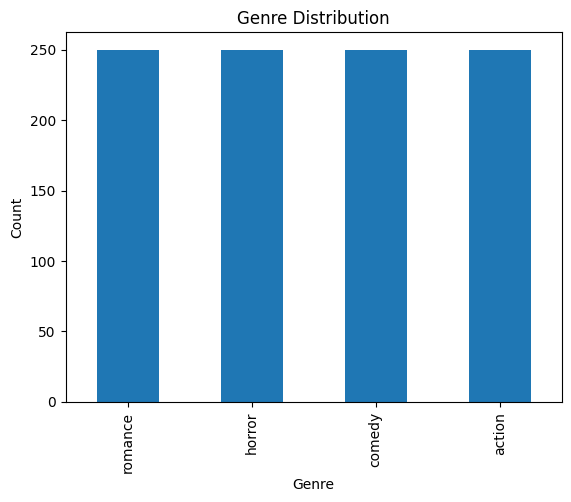

In [ ]:
df['genre'].value_counts().plot(kind='bar')
plt.title('Genre Distribution')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.show()

In [ ]:
print(df['description'][3])

Abby Holland (Kristen Stewart) and Harper Caldwell (Mackenzie Davis) are a couple who have been dating nearly a year. Abby dislikes Christmas since her parents passed away a few year earlier, so Harper spontaneously invites Abby to celebrate the holidays with her family in her hometown of Pittsburgh. Abby sees this as the perfect opportunity to introduce herself to Harper's parents and propose to her on Christmas morning. However, on their way to the Caldwells' house, Harper reveals she lied to Abby about coming out to her parents; fearing doing so would interfere with her father's campaign for mayor, she doesn't want to come out to her family until after Christmas. She asks Abby to pretend to be her straight roommate for the holiday, to which Abby reluctantly agrees.

At the Caldwells' house, Abby meets Harper's father, Ted (Victor Garber), her perfectionist mother, Tipper (Mary Streenburgen), and her wacky younger sister, Jane (Mary Holland). The family welcomes Abby as Harper's "orp

In [ ]:
print(type(df['description'][3]))

<class 'str'>


In [ ]:
df.isna().sum()

,0
movie_id,0
description,0
genre,0


In [ ]:
# map the string genres to integers
genre_to_nums = {'romance':1, 'horror':2, 'comedy':3, 'action':4}

df['genre_map'] = df['genre'].map(genre_to_nums)
df.head()

,movie_id,description,genre,genre_map
0,tt12783454,Elle Evans (Joey King) has finally completed h...,romance,1
1,tt1798632,A young girl tries to understand how she myste...,horror,2
2,tt9214832,"In 1800s England, a well meaning but selfish y...",comedy,3
3,tt8522006,Abby Holland (Kristen Stewart) and Harper Cald...,romance,1
4,tt21249656,Olga and Maks are 15 years apart. She is a suc...,romance,1


### 2. Clean the movie summary column in any way you see fit.

Going to remove the actors names in parenthesis because I don't think they are going to be predictive of genre generally - obviously can change

In [ ]:
def remove_actors(text):
  #get rid of opening parenthesis, multiple characters that are not parenthesis, and closing parenthesis
  no_actors = re.sub(r'\([^)]+\)', '', text)

  #only keep letters, lowercase, and get rid of punctuation
  clean_text = re.sub(r'[^a-zA-Z]', ' ', no_actors.lower())

  # Optional: Clean up double spaces left behind
  return clean_text.strip().replace('  ', ' ')

In [ ]:
df['Clean_Summary'] = df['description'].apply(remove_actors)

In [ ]:
print(df['Clean_Summary'][3])

abby holland and harper caldwell are a couple who have been dating nearly a year abby dislikes christmas since her parents passed away a few year earlier so harper spontaneously invites abby to celebrate the holidays with her family in her hometown of pittsburgh abby sees this as the perfect opportunity to introduce herself to harper s parents and propose to her on christmas morning however on their way to the caldwells house harper reveals she lied to abby about coming out to her parents fearing doing so would interfere with her father s campaign for mayor she doesn t want to come out to her family until after christmas she asks abby to pretend to be her straight roommate for the holiday to which abby reluctantly agrees  at the caldwells house abby meets harper s father ted  her perfectionist mother tipper  and her wacky younger sister jane  the family welcomes abby as harper s orphan friend who has nowhere else to go for christmas abby quickly becomes uncomfortable especially when sh

### 3. Build a summarization tool and summarize a few of the movies.

Tokenize

** Possibly need to remove \n but I'm not sure

In [ ]:
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [ ]:
lemmatizer = WordNetLemmatizer() #import lemmatizer

stop_words = set(stopwords.words('english')).union(set(string.punctuation)) #get stopwords

def tokenize(text):
  raw_tokens = word_tokenize(text)

  filtered_tokens = []
  for word in raw_tokens:
      #double check for stop words and empty strings
      if word not in stop_words and len(word) > 1:
          #lemmatize
          lemma = lemmatizer.lemmatize(word)
          filtered_tokens.append(lemma)

  #rejoin to one string
  return ' '.join(filtered_tokens)

In [ ]:
nlp = spacy.load("en_core_web_sm")

def remove_numbers_spacy(text):
    doc = nlp(text)
    # Join tokens only if they aren't numbers (1, 2, 3) or number-words (one, two)
    return " ".join([token.text for token in doc if not token.like_num])

In [ ]:
df['Tokenized_Summary'] = df['Clean_Summary'].apply(tokenize)

In [ ]:
print(df['Tokenized_Summary'][3])

abby holland harper caldwell couple dating nearly year abby dislike christmas since parent passed away year earlier harper spontaneously invite abby celebrate holiday family hometown pittsburgh abby see perfect opportunity introduce harper parent propose christmas morning however way caldwell house harper reveals lied abby coming parent fearing would interfere father campaign mayor want come family christmas asks abby pretend straight roommate holiday abby reluctantly agrees caldwell house abby meet harper father ted perfectionist mother tipper wacky younger sister jane family welcome abby harper orphan friend nowhere else go christmas abby quickly becomes uncomfortable especially meet harper ex boyfriend connor girlfriend riley visit begin questioning much know girlfriend see ted tipper high expectation harper competitive relationship older sister sloane meanwhile ted trying impress possible donor city council contribute campaign abby unwillingly jeopardizes sloane child put unpaid ne

In [ ]:
print(type(df['Tokenized_Summary'][3]))

<class 'str'>


In [ ]:
df['Final_Summary'] = df['Tokenized_Summary'].apply(remove_numbers_spacy)

In [ ]:
df['Final_Summary'][3]

'abby holland harper caldwell couple dating nearly year abby dislike christmas since parent passed away year earlier harper spontaneously invite abby celebrate holiday family hometown pittsburgh abby see perfect opportunity introduce harper parent propose christmas morning however way caldwell house harper reveals lied abby coming parent fearing would interfere father campaign mayor want come family christmas asks abby pretend straight roommate holiday abby reluctantly agrees caldwell house abby meet harper father ted perfectionist mother tipper wacky younger sister jane family welcome abby harper orphan friend nowhere else go christmas abby quickly becomes uncomfortable especially meet harper ex boyfriend connor girlfriend riley visit begin questioning much know girlfriend see ted tipper high expectation harper competitive relationship older sister sloane meanwhile ted trying impress possible donor city council contribute campaign abby unwillingly jeopardizes sloane child put unpaid n

### Summary Tool

In [ ]:
def spacy_summarizer(text, limit=2):
    #load the model and process the text
    nlp = spacy.load('en_core_web_sm')
    doc = nlp(text)

    #build a frequency table for words
    word_frequencies = {}
    for word in doc:
        #ignore stop words and punctuation
        if word.text.lower() not in STOP_WORDS and word.text.lower() not in punctuation:
            if word.text not in word_frequencies.keys():
                word_frequencies[word.text] = 1
            else:
                word_frequencies[word.text] += 1

    #normalize frequencies (divide by max frequency)
    max_frequency = max(word_frequencies.values())
    for word in word_frequencies.keys():
        word_frequencies[word] = word_frequencies[word] / max_frequency

    #score the sentences
    sentence_tokens = [sent for sent in doc.sents]
    sentence_scores = {}
    for sent in sentence_tokens:
        for word in sent:
            if word.text.lower() in word_frequencies.keys():
                if sent not in sentence_scores.keys():
                    sentence_scores[sent] = word_frequencies[word.text.lower()]
                else:
                    sentence_scores[sent] += word_frequencies[word.text.lower()]

    #select the top N sentences
    summary = nlargest(limit, sentence_scores, key=sentence_scores.get)
    final_summary = [word.text for word in summary]
    return " ".join(final_summary)

In [ ]:
spacy_summarizer(df['description'][3], limit=2)

"However, on their way to the Caldwells' house, Harper reveals she lied to Abby about coming out to her parents; fearing doing so would interfere with her father's campaign for mayor, she doesn't want to come out to her family until after Christmas. John follows Abby outside, where the two talk about their stories of coming out to their respective families: Abby's parents were loving and accepting, while John's bigoted and homophobic father threw him out of the house and publicly disowned him forever."

In [ ]:
df['Summary'] = df['description'].apply(lambda x: spacy_summarizer(x, limit=2))

In [ ]:
print(df['description'][2])

In 1800s England, a well meaning but selfish young woman meddles in the love lives of her friends. Jane Austen's beloved comedy about finding your equal and earning your happy ending, is reimagined in this. Handsome, clever, and rich, Emma Woodhouse is a restless queen bee without rivals in her sleepy little town. In this glittering satire of social class and the pain of growing up, Emma must adventure through misguided matches and romantic missteps to find the love that has been there all along. Miss Taylor's wedding to Mr Weston is a sad day for Mr Woodhouse, but they go to church nonetheless. Emma has orchestrated the match. After the wedding party with Miss and Mrs Bates, Mr Knightly shows up. Mr Frank Churchill, Mr Weston's son - does not. Miss Harriet Smith comes to visit and becomes Emma's new friend. Emma starts making a match for Harriet and Mr Elton, the vicar. Harriet looks to Emma for everything. Harriet is in love with Mr Robert Martin - a farmer, but Emma persuades her to

In [ ]:
print(df['Summary'][2])

In this glittering satire of social class and the pain of growing up, Emma must adventure through misguided matches and romantic missteps to find the love that has been there all along. In 1800s England, a well meaning but selfish young woman meddles in the love lives of her friends.


In [ ]:
print(df['description'][25])

Madness ensues when a 'player' in the world of romantic relationships finds a girl who's a worthy opponent, that believes love is a battle of wits. Mickey belongs to a well-known business family, as a side business he along with his friend Dabbas help couples to separate who are not happy in their relationships.During bachelor-rate of Dabbas he meets Tinni and both fall in love after lot of hide and seek in relationship.Mickey and Tinni's parents agree for their marriage but Tinni finds that Mickey's family is quite possessive about him.Tinni feels that she won't be able to adjust in his family as she wants her own space.Tinni contacts for advise in breaking her relationship not knowing that she is speaking to none other then Mickey. 'Rohan "Mickey" Arora (Ranbir Kapoor) is the son of Ramesh Arora (Boney Kapoor), a rich Punjabi business magnate, and lives with his family (Mother Renu (Dimple Kapadia), sister Minny (Hasleen Kaur) & brother-in-law Ashish (Amber Rana). Niece Sweetu (Inaya

In [ ]:
print(df['Summary'][25])

Knowing that Mickey loves his family dearly and not wanting to make him choose between her and his family, she wants to breakup with him.\nMickey does not want to leave his family for her, and decides to go ahead with breaking off the marriage. Mickey's family meets Tinni's family at Manu's wedding and thus the Malhotra's find out about their daughter's love affair with Mickey.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
df['Final_Summary'][3]

'abby holland harper caldwell couple dating nearly year abby dislike christmas since parent passed away year earlier harper spontaneously invite abby celebrate holiday family hometown pittsburgh abby see perfect opportunity introduce harper parent propose christmas morning however way caldwell house harper reveals lied abby coming parent fearing would interfere father campaign mayor want come family christmas asks abby pretend straight roommate holiday abby reluctantly agrees caldwell house abby meet harper father ted perfectionist mother tipper wacky younger sister jane family welcome abby harper orphan friend nowhere else go christmas abby quickly becomes uncomfortable especially meet harper ex boyfriend connor girlfriend riley visit begin questioning much know girlfriend see ted tipper high expectation harper competitive relationship older sister sloane meanwhile ted trying impress possible donor city council contribute campaign abby unwillingly jeopardizes sloane child put unpaid n

In [ ]:
df.head()

,movie_id,description,genre,genre_map,Clean_Summary,Tokenized_Summary,Final_Summary,Summary
0,tt12783454,Elle Evans (Joey King) has finally completed h...,romance,1,elle evans has finally completed high school a...,elle evans finally completed high school go ro...,elle evans finally completed high school go ro...,"Back at the beach house, Chloe (Maisie Richard..."
1,tt1798632,A young girl tries to understand how she myste...,horror,2,a young girl tries to understand how she myste...,young girl try understand mysteriously gained ...,young girl try understand mysteriously gained ...,"In another flashback, a young Andy and his gir..."
2,tt9214832,"In 1800s England, a well meaning but selfish y...",comedy,3,in s england a well meaning but selfish youn...,england well meaning selfish young woman meddl...,england well meaning selfish young woman meddl...,In this glittering satire of social class and ...
3,tt8522006,Abby Holland (Kristen Stewart) and Harper Cald...,romance,1,abby holland and harper caldwell are a couple ...,abby holland harper caldwell couple dating nea...,abby holland harper caldwell couple dating nea...,"However, on their way to the Caldwells' house,..."
4,tt21249656,Olga and Maks are 15 years apart. She is a suc...,romance,1,olga and maks are years apart she is a succes...,olga mak year apart successful woman establish...,olga mak year apart successful woman establish...,She is a successful woman with an established ...


In [ ]:
import pickle

with open('/content/drive/MyDrive/movies.pkl', 'wb') as f:
    pickle.dump(df, f)

### Naive Bayes Modeling

In [ ]:
df.head()

,movie_id,description,genre,genre_map,Clean_Summary,Tokenized_Summary,Final_Summary,Summary
0,tt12783454,Elle Evans (Joey King) has finally completed h...,romance,1,elle evans has finally completed high school a...,elle evans finally completed high school go ro...,elle evans finally completed high school go ro...,"Back at the beach house, Chloe (Maisie Richard..."
1,tt1798632,A young girl tries to understand how she myste...,horror,2,a young girl tries to understand how she myste...,young girl try understand mysteriously gained ...,young girl try understand mysteriously gained ...,"In another flashback, a young Andy and his gir..."
2,tt9214832,"In 1800s England, a well meaning but selfish y...",comedy,3,in s england a well meaning but selfish youn...,england well meaning selfish young woman meddl...,england well meaning selfish young woman meddl...,In this glittering satire of social class and ...
3,tt8522006,Abby Holland (Kristen Stewart) and Harper Cald...,romance,1,abby holland and harper caldwell are a couple ...,abby holland harper caldwell couple dating nea...,abby holland harper caldwell couple dating nea...,"However, on their way to the Caldwells' house,..."
4,tt21249656,Olga and Maks are 15 years apart. She is a suc...,romance,1,olga and maks are years apart she is a succes...,olga mak year apart successful woman establish...,olga mak year apart successful woman establish...,She is a successful woman with an established ...


In [ ]:
X = df['Final_Summary'] #create X
y = df['genre_map'] #create y

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) #make train/test split

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
# vectorizer = CountVectorizer(min_df=5) #import vectorizer
vectorizer = TfidfVectorizer(stop_words='english', max_df=0.7)
X_train_dtm = vectorizer.fit_transform(X_train) #make train document term matrix
X_test_dtm = vectorizer.transform(X_test) #make test document term matrix

In [ ]:
from sklearn.naive_bayes import MultinomialNB
model = MultinomialNB() #define multinomial bayes model
model.fit(X_train_dtm, y_train) #fit on train document term matrix and y_train
print(f'{model.score(X_test_dtm, y_test)=}')

model.score(X_test_dtm, y_test)=0.72


In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

preds = model.predict_proba(X_test_dtm) #predict on test set

preds /= preds.sum(axis=1)[..., np.newaxis] #normalize so they are all 0 to 1

y_pred_nb = model.predict(X_test_dtm)

#classification report
print(classification_report(y_test, y_pred_nb))

              precision    recall  f1-score   support

           1       0.67      0.64      0.66        45
           2       0.87      0.78      0.82        60
           3       0.46      0.53      0.49        40
           4       0.82      0.85      0.84        55

    accuracy                           0.72       200
   macro avg       0.71      0.70      0.70       200
weighted avg       0.73      0.72      0.72       200



In [ ]:
print(f'{accuracy_score(y_test, y_pred_nb)=}') #get accuracy

accuracy_score(y_test, y_pred_nb)=0.72


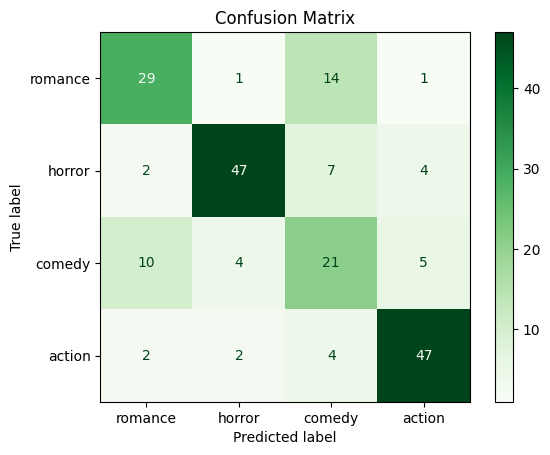

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred_nb)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['romance', 'horror','comedy','action'])
disp.plot(cmap=plt.cm.Greens)
plt.title('Confusion Matrix')
plt.show()

In [ ]:
def get_top_features(vectorizer, model, n=10):
    #get the actual word names from the vectorizer
    feature_names = vectorizer.get_feature_names_out()

    #loop through 4 classes
    for i, class_label in enumerate(model.classes_):
        #sort the log-probabilities for the current class
        top_indices = np.argsort(model.feature_log_prob_[i])[-n:]

        #pull the corresponding words
        top_words = [feature_names[idx] for idx in top_indices]

        print(f"Top words for Class {class_label}:")
        print(", ".join(top_words))
        print("-" * 30)

In [ ]:
get_top_features(vectorizer, model)

Top words for Class 1:
father, mother, story, year, meet, young, relationship, woman, life, love
------------------------------
Top words for Class 2:
begin, woman, home, town, friend, young, girl, night, house, family
------------------------------
Top words for Class 3:
high, christmas, mother, new, make, year, school, family, friend, life
------------------------------
Top words for Class 4:
kill, assassin, soldier, criminal, son, life, mission, man, team, world
------------------------------


### Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
logistic_model = LogisticRegression(max_iter=1000) #set up logistic regression model
logistic_model.fit(X_train_dtm, y_train) #fit on document term matrices

LogisticRegression(max_iter=1000)

In [ ]:
preds_log = logistic_model.predict_proba(X_test_dtm) #predict on test set

In [ ]:
preds_log /= preds_log.sum(axis=1)[..., np.newaxis] #normalize so they are all 0 to 1

In [ ]:
preds_log_notprob = logistic_model.predict(X_test_dtm)

#classification report
print(classification_report(y_test, preds_log_notprob))

              precision    recall  f1-score   support

           1       0.59      0.64      0.62        45
           2       0.82      0.82      0.82        60
           3       0.44      0.38      0.41        40
           4       0.79      0.82      0.80        55

    accuracy                           0.69       200
   macro avg       0.66      0.66      0.66       200
weighted avg       0.68      0.69      0.69       200



In [ ]:
print(f'{accuracy_score(y_test, preds_log_notprob)=}') #get accuracy

accuracy_score(y_test, preds_log_notprob)=0.69


In [ ]:
words = vectorizer.get_feature_names_out() #get words from model features

In [ ]:
def get_logreg_features(vectorizer, model, n=10):
    words = vectorizer.get_feature_names_out()

    # model.classes_ contains 4 labels
    for i, class_name in enumerate(model.classes_):
        # get coefficients for this specific class
        coeffs = model.coef_[i]

        #create a temp DataFrame for this class
        df = pd.DataFrame({'Word': words, 'Coefficient': coeffs})

        #sort by coefficient (Highest = Most Positive Impact)
        top_features = df.sort_values(by='Coefficient', ascending=False).head(n)

        print(f"Top 10 Words for Class: {class_name}")
        print(top_features.to_string(index=False))
        print("-" * 30)

#run it!
get_logreg_features(vectorizer, logistic_model)

Top 10 Words for Class: 1
        Word  Coefficient
        love     2.729625
relationship     1.218872
        meet     0.957013
       tessa     0.766356
    marriage     0.755339
   christian     0.715151
       woman     0.672288
       henry     0.649901
      hardin     0.642257
      affair     0.633477
------------------------------
Top 10 Words for Class: 2
     Word  Coefficient
    night     1.155805
   horror     1.113436
    demon     1.094571
     dark     1.043463
    house     1.039517
nightmare     0.995665
     town     0.800886
    begin     0.793721
    sarah     0.793396
     evil     0.778618
------------------------------
Top 10 Words for Class: 3
     Word  Coefficient
   friend     0.929372
   school     0.865538
     kate     0.821188
   senior     0.750752
      kid     0.733034
christmas     0.724800
     high     0.717549
     star     0.705377
      max     0.693137
     make     0.684191
------------------------------
Top 10 Words for Class: 4
     Word  

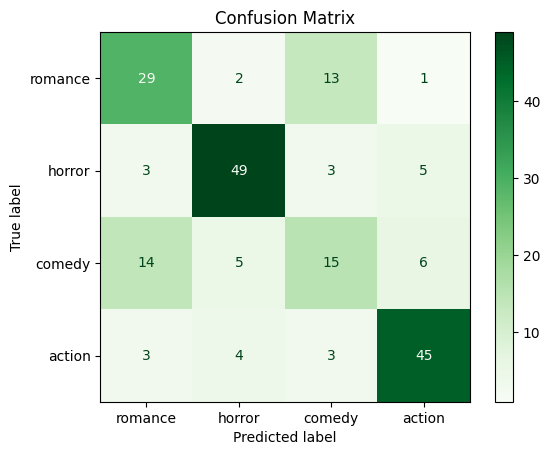

In [ ]:
cm_log = confusion_matrix(y_test, preds_log_notprob)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_log, display_labels=['romance', 'horror','comedy','action'])
disp.plot(cmap=plt.cm.Greens)
plt.title('Confusion Matrix')
plt.show()

In [ ]:
from joblib import dump

dump(vectorizer, 'tfidf_vectorizer.joblib')
dump(model, 'naive_bayes.joblib')
dump(logistic_model, 'logistic.joblib')

['logistic.joblib']

### LSTM

In [ ]:
# Tokenize summaries

tokenizer = Tokenizer(filters="")
tokenizer.fit_on_texts(X_train)
print(tokenizer)

In [ ]:
# save tokenizer

import pickle

with open('keras_tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

In [ ]:
# download tokenizer to local machine

from google.colab import files

files.download('keras_tokenizer.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# import tokenizer

with open('keras_tokenizer.pkl', 'rb') as f:
    tokenizer = pickle.load(f)

In [ ]:
# Word index result from fit_on_texts

word_index = tokenizer.word_index
print(len(word_index))
list(word_index.items())[:16]

15001


[('life', 1),
 ('find', 2),
 ('get', 3),
 ('go', 4),
 ('family', 5),
 ('friend', 6),
 ('take', 7),
 ('back', 8),
 ('year', 9),
 ('time', 10),
 ('love', 11),
 ('new', 12),
 ('day', 13),
 ('mother', 14),
 ('father', 15),
 ('tell', 16)]

In [ ]:
# Prepare input data for neural network

# define max sequence length
MAX_SEQUENCE_LENGTH = 50

# turn text into sequence of integers
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# pad sequences to the same length
X_train_lstm = pad_sequences(X_train_seq,maxlen=MAX_SEQUENCE_LENGTH,padding='post',
                     truncating='post')
X_test_lstm = pad_sequences(X_test_seq,maxlen=MAX_SEQUENCE_LENGTH,padding='post',
                     truncating='post')


In [ ]:
# Get premade embeddings

def get_embeddings(file_name):
    embeddings_index = {}
    with open(file_name, encoding="utf8") as f:
        for line in f:
            values = line.rstrip().split(' ')
            if len(values) > 2:
                embeddings_index[values[0]] = np.asarray(values[1:], dtype="float32")
    return embeddings_index

In [ ]:
# Get FastText embeddings

# URL and paths
url = "https://dl.fbaipublicfiles.com/fasttext/vectors-english/wiki-news-300d-1M.vec.zip"
zip_name = "wiki-news-300d-1M.vec.zip"
file_name = "wiki-news-300d-1M.vec"

# download zip file if doesn't exist
if not os.path.exists(zip_name) and not os.path.exists(file_name):
    print("Downloading FastText embeddings")
    response = requests.get(url, stream=True)
    with open(zip_name, "wb") as f:
        for chunk in response.iter_content(chunk_size=8192):
            f.write(chunk)
    print("Download complete")

# unzip file
if os.path.exists(zip_name) and not os.path.exists(file_name):
    print("Unzipping file")
    with zipfile.ZipFile(zip_name, "r") as zip_ref:
        zip_ref.extractall(".")
    os.remove(zip_name)
    print("File ready")

# get embeddings from file
embeddings_index = get_embeddings(file_name)

Download complete
Unzipping file
File ready


In [ ]:
# make embedding matrix

def get_embedding_matrix(word_index,embeddings_index, embeddings_dim=300):
    nb_words = len(word_index) + 1 # +1 since min(word_index.values())=1
    embedding_matrix = np.zeros((nb_words,embeddings_dim))
    unknown = 0
    for word, i in word_index.items():
        embedding_vector = embeddings_index.get(word)
        if embedding_vector is None: unknown += 1
        else: embedding_matrix[i] = embedding_vector
    return embedding_matrix, unknown

In [ ]:
# create and save embedding layer

EMBEDDING_LAYER_FILE = 'embedding_layer.pkl'

def make_save_emb_layer(word_index, embeddings_index, layer_file_name):
    embedding_matrix, unknown = get_embedding_matrix(word_index, embeddings_index)
    embedding_layer = Embedding(embedding_matrix.shape[0], embedding_matrix.shape[1],
                                weights=[embedding_matrix], trainable=False)
    with open(layer_file_name, 'wb') as f:
        pickle.dump(embedding_layer, f, -1)
    return unknown

print(make_save_emb_layer(word_index, embeddings_index, EMBEDDING_LAYER_FILE), 'unknown words')

2490 unknown words


In [ ]:
# Check embeddings

embeddings_index['here']

array([-1.540e-02, -1.460e-02, -4.300e-03, -4.870e-02,  6.780e-02,
       -5.090e-02, -6.000e-03, -5.360e-02,  4.140e-02,  1.960e-02,
        3.200e-02, -4.030e-02,  4.580e-02,  1.800e-02,  7.210e-02,
        1.200e-02,  2.800e-03, -1.106e-01,  4.500e-03, -4.290e-02,
       -1.552e-01, -6.350e-02,  6.850e-02,  7.260e-02, -9.870e-02,
       -1.795e-01, -4.310e-02, -2.920e-02,  1.000e-02,  8.000e-02,
        1.048e-01, -5.710e-02,  3.640e-02,  4.850e-02,  3.600e-03,
        1.650e-02, -7.900e-02,  6.960e-02,  1.470e-02,  5.600e-02,
       -2.700e-03, -2.530e-02, -3.290e-02, -4.750e-02, -1.810e-02,
       -3.270e-02, -7.290e-02, -2.190e-02,  1.300e-02, -1.020e-02,
        8.960e-02,  1.850e-02, -6.385e-01, -2.540e-02,  5.500e-03,
       -1.400e-03, -3.520e-02, -2.980e-02,  3.250e-02, -3.920e-02,
        7.450e-02,  2.640e-02, -5.670e-02, -1.107e-01, -3.650e-02,
        1.031e-01, -6.280e-02, -4.980e-02, -6.010e-02, -1.650e-02,
       -1.600e-03,  1.460e-02,  2.200e-02, -7.600e-03,  5.480e

In [ ]:
# check match rate of known words in text

unknown_count = make_save_emb_layer(word_index, embeddings_index, EMBEDDING_LAYER_FILE)
total_words = len(word_index)
match_rate = ((total_words - unknown_count) / total_words) * 100
print(f"Total vocabulary: {total_words}")
print(f"Unknown words: {unknown_count}")
print(f"Match Rate: {match_rate:.2f}%")

Total vocabulary: 17491
Unknown words: 2490
Match Rate: 85.76%


In [ ]:
# adjust class labels to start at 0 to match index instead of 1

y_train = y_train - 1
y_test = y_test - 1

# check output

print("New training labels:", np.unique(y_train))
print("New testing labels:", np.unique(y_test))

New training labels: [0 1 2 3]
New testing labels: [0 1 2 3]


#### Build, train, and save model

In [ ]:
# build LSTM model (4-class multiclass classification)

NUM_CLASSES = 4

def get_model():
    input_layer = Input(shape=(MAX_SEQUENCE_LENGTH,))
    x = embedding_layer(input_layer)
    x = SpatialDropout1D(0.3)(x)
    x = LSTM(64, return_sequences=True)(x)
    x = Conv1D(32, kernel_size=3, padding="valid", activation='relu')(x)
    x = GlobalMaxPooling1D()(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    x = Dense(32, activation='relu')(x)
    # 4 output neurons with softmax for multiclass
    output_layer = Dense(NUM_CLASSES, activation="softmax")(x)
    model = Model(inputs=input_layer, outputs=output_layer)
    model.compile(
        loss="sparse_categorical_crossentropy",
        optimizer=Adam(learning_rate=1e-3),
        metrics=["accuracy"]
    )
    return model

In [ ]:
with open(EMBEDDING_LAYER_FILE, 'rb') as f: embedding_layer = pickle.load(f)

In [ ]:
best_model_path = 'best_lstm_model.weights.h5'
BATCH_SIZE = 64 # smaller batch size for more frequent weight updates

early_stopping = EarlyStopping(patience=5, restore_best_weights=True)
model_checkpoint = ModelCheckpoint(best_model_path,
                                   save_best_only=True, save_weights_only=True,
                                   monitor='val_accuracy', mode='max')
lstm_model = get_model()
print(lstm_model.summary())

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_1 (Embedding)         │ (None, 50, 300)        │     5,247,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 50, 300)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 50, 64)         │        93,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 48, 32)         │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 32)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,348,532 (20.40 MB)

 Trainable params: 100,868 (394.02 KB)

 Non-trainable params: 5,247,664 (20.02 MB)

None


In [ ]:
hist_lstm = lstm_model.fit(
    X_train_lstm, y_train,
    validation_data=(X_test_lstm, y_test),
    epochs=50, batch_size=BATCH_SIZE, shuffle=True, verbose=2,
    callbacks=[model_checkpoint, early_stopping]
)
lstm_model.load_weights(best_model_path)

Epoch 1/50
13/13 - 9s - 695ms/step - accuracy: 0.3038 - loss: 1.5078 - val_accuracy: 0.3000 - val_loss: 1.3690
Epoch 2/50
13/13 - 0s - 21ms/step - accuracy: 0.3400 - loss: 1.3714 - val_accuracy: 0.3000 - val_loss: 1.3632
Epoch 3/50
13/13 - 0s - 28ms/step - accuracy: 0.4162 - loss: 1.2628 - val_accuracy: 0.3650 - val_loss: 1.3488
Epoch 4/50
13/13 - 0s - 28ms/step - accuracy: 0.5050 - loss: 1.1354 - val_accuracy: 0.4400 - val_loss: 1.3206
Epoch 5/50
13/13 - 0s - 29ms/step - accuracy: 0.5537 - loss: 1.0315 - val_accuracy: 0.4450 - val_loss: 1.2856
Epoch 6/50
13/13 - 0s - 27ms/step - accuracy: 0.5962 - loss: 0.9638 - val_accuracy: 0.5000 - val_loss: 1.2304
Epoch 7/50
13/13 - 0s - 28ms/step - accuracy: 0.6300 - loss: 0.9029 - val_accuracy: 0.5600 - val_loss: 1.1785
Epoch 8/50
13/13 - 0s - 28ms/step - accuracy: 0.6562 - loss: 0.8232 - val_accuracy: 0.6050 - val_loss: 1.1253
Epoch 9/50
13/13 - 0s - 29ms/step - accuracy: 0.6700 - loss: 0.7992 - val_accuracy: 0.6350 - val_loss: 1.0755
Epoch 10/

In [ ]:
from google.colab import files

# save the model to the local temporary Colab runtime
model_name = 'lstm_genre_model.keras'
lstm_model.save(model_name)
print(f'Model saved to {model_name}.')

# browser download model file for user
if os.path.exists(model_name):
    files.download(model_name)
else:
    print("Model file not found.")

Model saved to lstm_genre_model.keras.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# load model from local machine in future sessions

from google.colab import files
import os

uploaded = files.upload()

model_name = 'lstm_genre_model.keras'

if model_name in uploaded:
    print(f"{model_name} successfully uploaded to runtime.")
else:
    print("Upload failed or file name does not match.")

Saving lstm_genre_model.keras to lstm_genre_model.keras
lstm_genre_model.keras successfully uploaded to runtime.


In [ ]:
lstm_model = load_model('lstm_genre_model.keras')

#### Classification report

In [ ]:
BATCH_SIZE = 64

# Run this in earlier cell or can run here
# adjust class labels to start at 0 to match index instead of 1
# y_train = y_train - 1
# y_test = y_test - 1

test_pred_proba = lstm_model.predict(X_test_lstm, batch_size=BATCH_SIZE, verbose=0)
test_pred_class = np.argmax(test_pred_proba, axis=1)

genre_names = ['romance', 'horror', 'comedy', 'action']
print('=== LSTM Classification Report ===')
print(classification_report(y_test, test_pred_class, target_names=genre_names))
print(f'Accuracy: {accuracy_score(y_test, test_pred_class):.4f}')
print(f'ROC-AUC (macro OvR): {roc_auc_score(y_test, test_pred_proba, multi_class="ovr", average="macro"):.4f}')

cm_lstm = confusion_matrix(y_test, test_pred_class)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lstm, display_labels=genre_names)
disp.plot(cmap=plt.cm.Blues)
plt.title('LSTM Confusion Matrix')
plt.show()

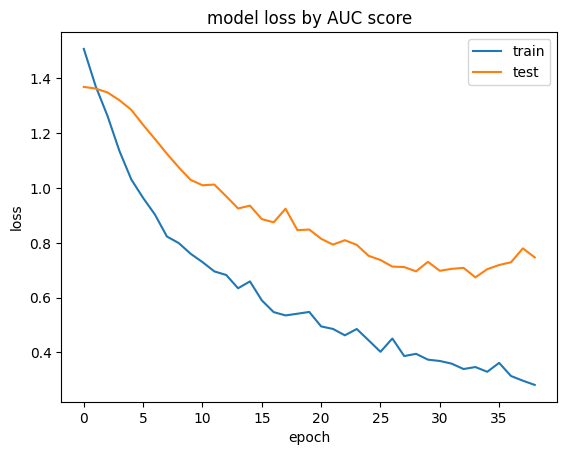

In [ ]:
# graph model loss

plt.plot(hist_lstm.history['loss'])
plt.plot(hist_lstm.history['val_loss'])
plt.title('model loss by AUC score')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper right')

#### For your tensorflow model(s), plot your models and plot accuracy over epoch number.

In [ ]:
# plot model architecture

plot_model(
    lstm_model,
    to_file='lstm_model_architecture.png',
    show_shapes=True,
    show_layer_names=True
)
print("Model architecture plot saved as 'lstm_model_architecture.png'")

Model architecture plot saved as 'lstm_model_architecture.png'


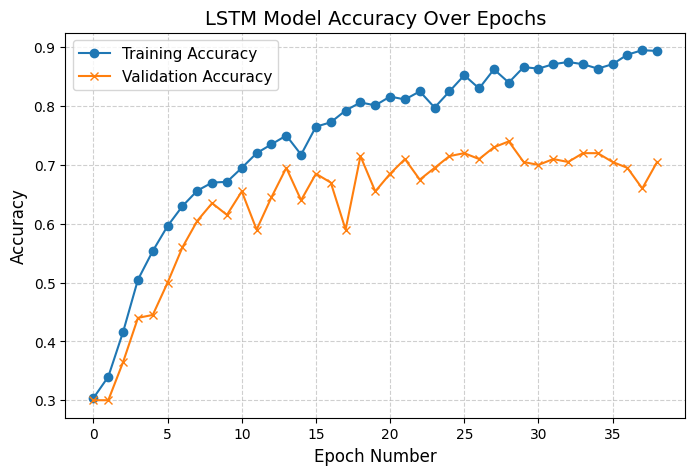

In [ ]:
# Plot accuracy

# plot training and validation accuracy
plt.figure(figsize=(8, 5))
plt.plot(hist_lstm.history['accuracy'], marker='o', label='Training Accuracy')
plt.plot(hist_lstm.history['val_accuracy'], marker='x', label='Validation Accuracy')

# format plot
plt.title('LSTM Model Accuracy Over Epochs', fontsize=14)
plt.xlabel('Epoch Number', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.xticks(range(0, len(hist_lstm.history['accuracy']), 5))  # ensures integer epoch numbers on x-axis
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)

# save and display plot
plt.savefig('lstm_accuracy_over_epochs.png', dpi=300)
plt.show()

#### Get features

In [ ]:
# feature names
lstm_model.layers

[<InputLayer name=input_layer_2, built=True>,
 <Embedding name=embedding_1, built=True>,
 <SpatialDropout1D name=spatial_dropout1d_2, built=True>,
 <LSTM name=lstm_2, built=True>,
 <Conv1D name=conv1d_2, built=True>,
 <GlobalMaxPooling1D name=global_max_pooling1d_2, built=True>,
 <BatchNormalization name=batch_normalization_2, built=True>,
 <Dropout name=dropout_2, built=True>,
 <Dense name=dense_4, built=True>,
 <Dense name=dense_5, built=True>]

In [ ]:
# model weights
embedding_weights = lstm_model.layers[1].get_weights()[0]

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
vectorizer = CountVectorizer(min_df=5) #import vectorizer

In [ ]:
# vocabulary
vocab = vectorizer.vocabulary_

In [ ]:
# calculate word scores as mean for each embedding array
word_scores = [np.mean(embedding_weights[vocab[word]]) for word in vocab]

In [ ]:
# grab the 6th layer (Global Max Pooling), no matter its name
pooling_model = Model(inputs=lstm_model.input,
                      outputs=lstm_model.get_layer(lstm_model.layers[5].name).output)

# extract feature activations for test data
features_extracted = pooling_model.predict(X_test_lstm, verbose=0)

# grab final Dense layer's classification weights
dense_weights = lstm_model.layers[-1].get_weights()[0]

# map using tokenizer
num_words = len(tokenizer.word_index) + 1
vocab_list = [""] * num_words
for word, i in tokenizer.word_index.items():
    if i < num_words:
        vocab_list[i] = word

# empty dictionary for scores
genre_dfs = {}

# calculate class-specific word impact scores
for class_idx, genre in enumerate(genre_names):
    # multiply activations by the specific classification weights for this genre
    class_feature_scores = features_extracted * dense_weights[:, class_idx]

    # initialize a clean array matching the size of vocab_list
    total_word_scores = np.zeros(len(vocab_list))

    # filter for samples that actually belong to this specific genre
    class_mask = (y_test == class_idx)

    # track which words were responsible for the highest pooling activations
    for i, is_in_class in enumerate(class_mask):
        if is_in_class:
            # find the unique token integers present in this specific movie description
            unique_tokens = np.unique(X_test_lstm[i])
            for token in unique_tokens:
                # ensure the token index is strictly inside the vocabulary array bounds
                if token != 0 and token < len(vocab_list):
                    # attribute the maximum activation score found in this sentence to the word
                    total_word_scores[token] += np.max(class_feature_scores[i])

    # create a data frame for the current genre
    df_genre = pd.DataFrame({
        'feature': vocab_list,
        'coefficient': total_word_scores
    })

    # Sort and get the top 10 rows (most important)
    top_10 = df_genre.sort_values('coefficient', ascending=False).head(10).reset_index(drop=True)
    genre_dfs[genre] = top_10

# print out the class-separated results
for genre in genre_names:
    print(f"\n=== Top 10 Most Influential Words for: {genre.upper()} ===")
    print(genre_dfs[genre])


=== Top 10 Most Influential Words for: ROMANCE ===
  feature  coefficient
0    love     1.750276
1    life     1.423407
2   young     1.408654
3  friend     1.141565
4    year     1.129018
5    meet     1.092375
6  family     1.070064
7  mother     1.037729
8    fall     0.844933
9   story     0.833879

=== Top 10 Most Influential Words for: HORROR ===
  feature  coefficient
0   young     2.969827
1    life     2.828592
2    find     2.340522
3    girl     1.870490
4   woman     1.837592
5   house     1.738434
6    come     1.727956
7    year     1.725453
8  family     1.678095
9    home     1.586344

=== Top 10 Most Influential Words for: COMEDY ===
  feature  coefficient
0    life     1.254799
1  friend     1.157795
2    take     0.958224
3    meet     0.841720
4    year     0.813374
5     new     0.808979
6     day     0.696531
7   world     0.693426
8  family     0.690956
9     old     0.689102

=== Top 10 Most Influential Words for: ACTION ===
   feature  coefficient
0     must  

## BONUS (optional): extract the images and map them with the genre of movie. Build a model classifying the genre based on the movie images.

In [ ]:
import os
path += "/IMDB four_genre_posters/"
genres = os.listdir(path)
df = pd.DataFrame(columns=['genre','image_id', 'image_path'])

for genre in genres:
  genre_path = path + genre
  images = os.listdir(genre_path)
  new_df = pd.DataFrame(columns=['genre', 'image_id', 'image_path'])
  new_df["image_id"] = images
  new_df["genre"] = genre
  new_df['image_path'] = genre_path + "/" + new_df['image_id']
  df = pd.concat([df, new_df])


In [ ]:
df.drop_duplicates(subset='image_id', keep=False, inplace=True)

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
df_train, df_test = train_test_split(df, test_size=0.3, random_state = 42)

In [ ]:
from tensorflow.keras.layers import Dense, Dropout, Flatten,BatchNormalization, Conv2D, MaxPooling2D, GlobalAveragePooling2D, Input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, TensorBoard
from tensorflow.keras import backend as K
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
import tensorflow as tf

In [ ]:
img_height, img_width = 512, 512
batch_size = 64

train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=df_train,
    x_col='image_path',
    y_col='genre',
    classes = genres,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True                # Important to shuffle training data
)

test_generator = test_datagen.flow_from_dataframe(
    dataframe=df_test,
    x_col='image_path',
    y_col='genre',
    classes = genres,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False               # Keep False to maintain order for evaluation
)

Found 823 validated image filenames belonging to 4 classes.
Found 354 validated image filenames belonging to 4 classes.


In [ ]:
model = Sequential()

#first block
model.add(Input(shape=(512, 512, 3)))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))

#second block
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(BatchNormalization())
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

#block 3 - more filters
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(BatchNormalization())
model.add(Conv2D(128, (3, 3), activation='relu')) #extra layer for feature depth
model.add(GlobalAveragePooling2D())

#final layers
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))

#go to 27 classes and use sigmoid
model.add(Dense(4, activation='sigmoid'))

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy', #required for multi-label (sigmoid)
    metrics=['accuracy']
)

In [ ]:
import numpy as np
# Learning Rate Scheduler
# This function keeps the initial learning rate for the first 10 epochs
# and decreases it exponentially after that.
def scheduler(epoch, lr):
    if epoch < 10:
         return lr
    else:
        return lr * np.exp(-0.1)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
my_callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=10),
    tf.keras.callbacks.ModelCheckpoint(
        filepath='/content/drive/My Drive/best_posters_model.keras',
        save_best_only=True,
        monitor='val_accuracy',
        mode='max'
    ),
    tf.keras.callbacks.LearningRateScheduler(scheduler),
    tf.keras.callbacks.TensorBoard(log_dir='/content/drive/My Drive/logs'),
]

In [ ]:
model.summary()

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_59 (Conv2D)              │ (None, 510, 510, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_43          │ (None, 510, 510, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_29 (MaxPooling2D) │ (None, 255, 255, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_60 (Conv2D)              │ (None, 253, 253, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_44          │ (None, 253, 253, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_61 (Conv2D)              │ (None, 251, 251, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_30 (MaxPooling2D) │ (None, 125, 125, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_62 (Conv2D)              │ (None, 123, 123, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_45          │ (None, 123, 123, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_63 (Conv2D)              │ (None, 121, 121, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_14     │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 553,732 (2.11 MB)

 Trainable params: 553,092 (2.11 MB)

 Non-trainable params: 640 (2.50 KB)

In [ ]:
history = model.fit(train_generator,
          batch_size=batch_size,
          epochs=30,
          verbose=1,
          validation_data=test_generator,
          callbacks=my_callbacks)

Epoch 1/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 558ms/step - accuracy: 0.5358 - loss: 0.4475 - val_accuracy: 0.2825 - val_loss: 0.5735 - learning_rate: 0.0010
Epoch 2/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 548ms/step - accuracy: 0.5711 - loss: 0.4405 - val_accuracy: 0.4153 - val_loss: 0.5367 - learning_rate: 0.0010
Epoch 3/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 536ms/step - accuracy: 0.5723 - loss: 0.4257 - val_accuracy: 0.2797 - val_loss: 0.5468 - learning_rate: 0.0010
Epoch 4/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 545ms/step - accuracy: 0.5844 - loss: 0.4220 - val_accuracy: 0.2853 - val_loss: 0.5782 - learning_rate: 0.0010
Epoch 5/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 562ms/step - accuracy: 0.5759 - loss: 0.4219 - val_accuracy: 0.4718 - val_loss: 0.4915 - learning_rate: 0.0010
Epoch 6/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 542ms/step - accuracy: 0.5832 - loss: 0.4227 - val_accuracy: 0.4576 - val_loss: 0.4950 - learning_rate: 0.0010
Epoch 7/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 537ms/step - accuracy: 0.5990 - loss: 0.4125 - 

In [ ]:
# this is how to load in the saved transformer model
from tensorflow.keras.models import load_model

poster_model = load_model('best_posters_model.keras')

In [ ]:
# evaluate the final model

eval = poster_model.evaluate(test_generator)

print(f"Final Test Loss: {eval[0]:.4f}")
print(f"Final Test Accuracy: {eval[1]:.2%}")

6/6 ━━━━━━━━━━━━━━━━━━━━ 69s 5s/step - accuracy: 0.4209 - loss: 0.5299
Final Test Loss: 0.5299
Final Test Accuracy: 42.09%


6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 907ms/step


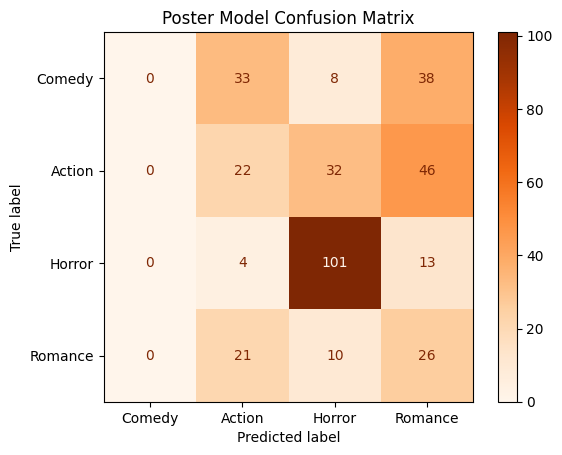

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

# Get true labels from the test generator
y_true = test_generator.classes

# Get predictions from the model
y_pred_proba = poster_model.predict(test_generator)

# Get predicted class labels (index of the highest probability)
y_pred_class = np.argmax(y_pred_proba, axis=1)

# Create confusion matrix
cm_poster = confusion_matrix(y_true, y_pred_class)

# Get display labels from the generator's class indices
display_labels = list(test_generator.class_indices.keys())

# Plot the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm_poster, display_labels=display_labels)
disp.plot(cmap=plt.cm.Oranges)
plt.title('Poster Model Confusion Matrix')
plt.show()

## Transformer Model

In [ ]:
from tensorflow.keras.layers import (MultiHeadAttention, LayerNormalization,
                                     GlobalAveragePooling1D, Add)
import tensorflow as tf

In [ ]:
class PositionalEncoding(tf.keras.layers.Layer):
    def __init__(self, max_len, d_model, **kwargs):
        super().__init__(**kwargs)
        self.max_len = max_len
        self.d_model = d_model

        positions = np.arange(max_len)[:, np.newaxis]
        dims = np.arange(d_model)[np.newaxis, :]
        angles = positions / np.power(10000, (2 * (dims // 2)) / d_model)
        angles[:, 0::2] = np.sin(angles[:, 0::2])
        angles[:, 1::2] = np.cos(angles[:, 1::2])
        self.pos_encoding = tf.cast(angles[np.newaxis, :, :], dtype=tf.float32)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        return x + self.pos_encoding[:, :seq_len, :]

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'max_len': self.max_len, 'd_model': self.d_model})
        return cfg

In [ ]:
def transformer_encoder_block(x, num_heads, ff_dim, dropout_rate=0.1):
    # Multi-Head Self-Attention
    attn_output = MultiHeadAttention(num_heads=num_heads, key_dim=x.shape[-1] // num_heads)(x, x)
    attn_output = Dropout(dropout_rate)(attn_output)
    x = LayerNormalization(epsilon=1e-6)(Add()([x, attn_output]))  # residual + norm

    # Feed-Forward Network
    ffn = Dense(ff_dim, activation='relu')(x)
    ffn = Dropout(dropout_rate)(ffn)
    ffn = Dense(x.shape[-1])(ffn)
    x = LayerNormalization(epsilon=1e-6)(Add()([x, ffn])) # residual + norm
    return x

In [ ]:
def get_transformer_model(num_classes=4, num_heads=4, ff_dim=128, num_transformer_blocks=2, dropout_rate=0.1, embeddings_dim=300):
    input_layer = Input(shape=(MAX_SEQUENCE_LENGTH,))

    x = embedding_layer(input_layer) # (batch, seq_len, 300)
    x = PositionalEncoding(max_len=MAX_SEQUENCE_LENGTH, d_model=embeddings_dim)(x)
    x = Dropout(dropout_rate)(x)

    for _ in range(num_transformer_blocks):
        x = transformer_encoder_block(x, num_heads=num_heads, ff_dim=ff_dim,
                                       dropout_rate=dropout_rate)

    x = GlobalAveragePooling1D()(x)
    x = Dropout(dropout_rate)(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(dropout_rate)(x)
    output_layer = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=input_layer, outputs=output_layer)
    model.compile(
        loss='sparse_categorical_crossentropy',
        optimizer=Adam(learning_rate=1e-4),
        metrics=['accuracy']
    )
    return model

transformer_model = get_transformer_model()
transformer_model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 50)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 50, 300)   │  5,247,600 │ input_layer_2[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_encodin… │ (None, 50, 300)   │          0 │ embedding_1[2][0] │
│ (PositionalEncodin… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_10          │ (None, 50, 300)   │          0 │ positional_encod… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 50, 300)   │    361,200 │ dropout_10[0][0], │
│ (MultiHeadAttentio… │                   │            │ dropout_10[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_12          │ (None, 50, 300)   │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 50, 300)   │          0 │ dropout_10[0][0], │
│                     │                   │            │ dropout_12[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 50, 300)   │        600 │ add_4[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 50, 128)   │     38,528 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_13          │ (None, 50, 128)   │          0 │ dense_8[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 50, 300)   │     38,700 │ dropout_13[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_5 (Add)         │ (None, 50, 300)   │          0 │ layer_normalizat… │
│                     │                   │            │ dense_9[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 50, 300)   │        600 │ add_5[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 50, 300)   │    361,200 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_15          │ (None, 50, 300)   │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_6 (Add)         │ (None, 50, 300)   │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_15[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 50, 300)   │        600 │ add_6[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 6,146,380 (23.45 MB)

 Trainable params: 898,780 (3.43 MB)

 Non-trainable params: 5,247,600 (20.02 MB)

In [ ]:
transformer_model = get_transformer_model()
best_transformer_path = 'best_transformer_model.weights.h5'

t_early_stopping = EarlyStopping(patience=12, restore_best_weights=True)
t_model_checkpoint = ModelCheckpoint(best_transformer_path,
                                      save_best_only=True, save_weights_only=True,
                                      monitor='val_accuracy', mode='max')

hist_transformer = transformer_model.fit(
    X_train_lstm, y_train,
    validation_data=(X_test_lstm, y_test),
    epochs=100, batch_size=64, shuffle=True, verbose=2,
    callbacks=[t_model_checkpoint, t_early_stopping]
)
transformer_model.load_weights(best_transformer_path)

Epoch 1/100
13/13 - 52s - 4s/step - accuracy: 0.2600 - loss: 1.4446 - val_accuracy: 0.3400 - val_loss: 1.3784
Epoch 2/100
13/13 - 1s - 41ms/step - accuracy: 0.2525 - loss: 1.4275 - val_accuracy: 0.2200 - val_loss: 1.3957
Epoch 3/100
13/13 - 0s - 32ms/step - accuracy: 0.2488 - loss: 1.4272 - val_accuracy: 0.2200 - val_loss: 1.3986
Epoch 4/100
13/13 - 1s - 45ms/step - accuracy: 0.2675 - loss: 1.3973 - val_accuracy: 0.2250 - val_loss: 1.4000
Epoch 5/100
13/13 - 0s - 31ms/step - accuracy: 0.2637 - loss: 1.3993 - val_accuracy: 0.2000 - val_loss: 1.4028
Epoch 6/100
13/13 - 0s - 31ms/step - accuracy: 0.2713 - loss: 1.3900 - val_accuracy: 0.2050 - val_loss: 1.3767
Epoch 7/100
13/13 - 0s - 37ms/step - accuracy: 0.2612 - loss: 1.3934 - val_accuracy: 0.2150 - val_loss: 1.3946
Epoch 8/100
13/13 - 0s - 29ms/step - accuracy: 0.2488 - loss: 1.3880 - val_accuracy: 0.2000 - val_loss: 1.3816
Epoch 9/100
13/13 - 0s - 27ms/step - accuracy: 0.2525 - loss: 1.3889 - val_accuracy: 0.2200 - val_loss: 1.4031
Ep

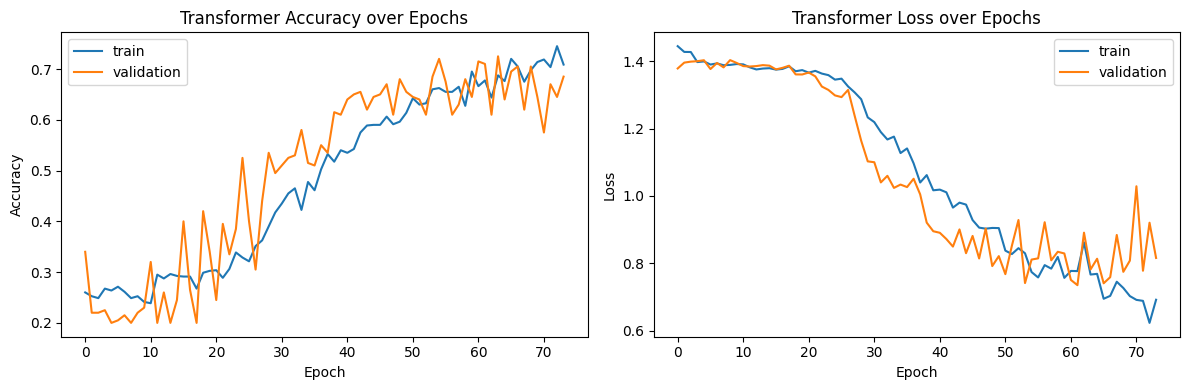

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(hist_transformer.history['accuracy'],     label='train')
axes[0].plot(hist_transformer.history['val_accuracy'], label='validation')
axes[0].set_title('Transformer Accuracy over Epochs')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(hist_transformer.history['loss'],     label='train')
axes[1].plot(hist_transformer.history['val_loss'], label='validation')
axes[1].set_title('Transformer Loss over Epochs')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# this is how to load in the saved transformer model
from tensorflow.keras.models import load_model

transformer_model = load_model('transformer_genre_model.keras',
                                custom_objects={'PositionalEncoding': PositionalEncoding})

Transformer Classification Report
              precision    recall  f1-score   support

     romance       0.79      0.58      0.67        45
      horror       0.78      0.85      0.82        60
      comedy       0.55      0.45      0.49        40
      action       0.72      0.91      0.81        55

    accuracy                           0.72       200
   macro avg       0.71      0.70      0.70       200
weighted avg       0.72      0.72      0.72       200

Accuracy: 0.7250
ROC-AUC (macro OvR): 0.8957


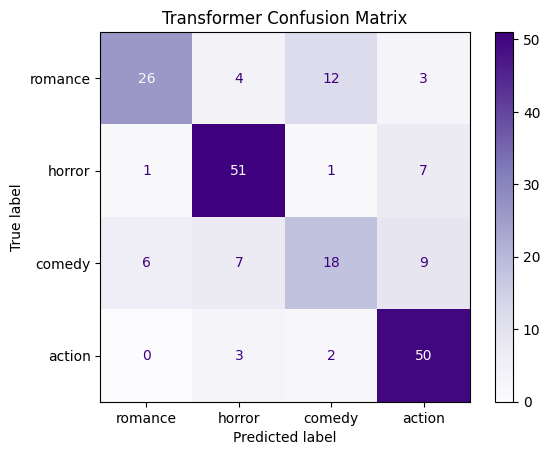

In [ ]:
t_pred_proba = transformer_model.predict(X_test_lstm, batch_size=256, verbose=0)
t_pred_class = np.argmax(t_pred_proba, axis=1)

genre_names = ['romance', 'horror', 'comedy', 'action']
print('Transformer Classification Report')
print(classification_report(y_test, t_pred_class, target_names=genre_names))
print(f'Accuracy: {accuracy_score(y_test, t_pred_class):.4f}')
print(f'ROC-AUC (macro OvR): {roc_auc_score(y_test, t_pred_proba, multi_class="ovr", average="macro"):.4f}')

cm_t = confusion_matrix(y_test, t_pred_class)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_t, display_labels=genre_names)
disp.plot(cmap=plt.cm.Purples)
plt.title('Transformer Confusion Matrix')
plt.show()

In [ ]:
# save the transformer model
transformer_model.load_weights(best_transformer_path)

model_name = 'transformer_genre_model.keras'
transformer_model.save(model_name)
print(f'Model saved to {model_name}.')

if os.path.exists(model_name):
    files.download(model_name)
else:
    print("Model file not found.")

Model saved to transformer_genre_model.keras.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Find movies that had a different prediction based on the model. Explain why you think those models predicted one genre vs. the other.



In [ ]:
# IF DIDN'T DO EARLIER

# adjust class labels to start at 0 to match index instead of 1

y_train = y_train - 1
y_test = y_test - 1

# check output

print("New training labels:", np.unique(y_train))
print("New testing labels:", np.unique(y_test))

In [ ]:
# get test rows from original df

test_df = df.loc[y_test.index]

# reverse genre mapping if adjusted index
reverse_mapping = {0: 'romance', 1: 'horror', 2: 'comedy', 3: 'action'}

In [ ]:
# reverse genre mapping if no adjusted index
reverse_mapping = {1: 'romance', 2: 'horror', 3: 'comedy', 4: 'action'}

### Naive Bayes

In [ ]:
# make data frame with movie titles, descriptions, and true vs. predicted genres

nb_results_df = pd.DataFrame({
    'movie_id': test_df['movie_id'],
    'description': test_df['description'],
    'final_summary': test_df['Final_Summary'],
    'y_test': y_test,
    'y_pred': y_pred_nb
})

# map genres
nb_results_df['y_test_genre'] = nb_results_df['y_test'].map(reverse_mapping)
nb_results_df['y_pred_genre'] = nb_results_df['y_pred'].map(reverse_mapping)

nb_results_df.head(10)


,movie_id,description,final_summary,y_test,y_pred,y_test_genre,y_pred_genre
521,tt21651560,"Witness a hellish vision of , as social isolat...",witness hellish vision social isolation analog...,2,2,horror,horror
737,tt8110330,The emotional journey of two hopelessly-in-lov...,emotional journey hopelessly love youngster yo...,1,1,romance,romance
740,tt1298644,Two con women one low rent and the other high ...,con woman low rent high class team take men wr...,3,3,comedy,comedy
660,tt14121726,"Forced to travel with her boyfriend, Laine beg...",forced travel boyfriend laine begin experience...,2,2,horror,horror
411,tt1433905,Veer is a struggling musician whose only sourc...,veer struggling musician whose source income w...,3,3,comedy,comedy
678,tt0397442,Privileged teens living on the Upper East Side...,privileged teen living upper east side new yor...,1,1,romance,romance
626,tt10121392,In a world where supervillains are commonplace...,world supervillains commonplace estranged chil...,4,4,action,action
513,tt21628198,TATE goes on a rampage to avenge his loyal and...,tate go rampage avenge loyal trusted foot sold...,4,4,action,action
859,tt10665342,The saga of Michael Myers and Laurie Strode co...,saga michael myers laurie strode come spinechi...,2,2,horror,horror
136,tt8760708,A robotics engineer at a toy company builds a ...,robotics engineer toy company build lifelike d...,2,3,horror,comedy


In [ ]:
# check counts of predicted/true genre to confirm matches confusion matrix

true_genres_nb = nb_results_df['y_test_genre'].value_counts()
pred_genres_nb = nb_results_df['y_pred_genre'].value_counts()

# totals confirmed
print(true_genres_nb)
print(pred_genres_nb)

y_test_genre
horror     60
action     55
romance    45
comedy     40
Name: count, dtype: int64
y_pred_genre
action     57
horror     54
comedy     46
romance    43
Name: count, dtype: int64


In [ ]:
# filter to mismatched true vs. predicted values and display

mismatches_nb = nb_results_df[nb_results_df['y_test'] != nb_results_df['y_pred']]
mismatches_nb.head()

,movie_id,description,final_summary,y_test,y_pred,y_test_genre,y_pred_genre
136,tt8760708,A robotics engineer at a toy company builds a ...,robotics engineer toy company build lifelike d...,2,3,horror,comedy
636,tt19623240,After Christopher Robin abandons them for coll...,christopher robin abandon college pooh piglet ...,2,3,horror,comedy
973,tt9894660,Wannabeadventurer Zoe freaks out when she fall...,wannabeadventurer zoe freak fall pregnant long...,3,1,comedy,romance
938,tt15553956,Love never hurt so good for two coworkers who ...,love never hurt good coworkers enter contractu...,3,1,comedy,romance
280,tt9411972,"A dead body is found and Catherine ""Kya"" Clark...",dead body found catherine kya clark accused mu...,1,3,romance,comedy


Example: True genre horror, predicted as comedy

In [ ]:
# full description text

import textwrap
wrapped_text = textwrap.fill(mismatches_nb['description'][636], width=80)
print(f'Full description: {wrapped_text}')

Full description: After Christopher Robin abandons them for college, Pooh and Piglet embark on a
bloody rampage as they search for a new source of food. The days of adventures
and merriment have come to an end, as Christopher Robin, now a young man, has
left Winnie-The-Pooh and Piglet to fend for themselves. As time passes, feeling
angry and abandoned, the two become feral. After getting a taste for blood,
Winnie-The-Pooh and Piglet set off to find a new source of food. It's not long
before their bloody rampage begins.


In [ ]:
# cleaned summary used for prediction

wrapped_text = textwrap.fill(mismatches_nb['final_summary'][636], width=80)
print(f'Final summary: {wrapped_text}')

Final summary: christopher robin abandon college pooh piglet embark bloody rampage search new
source food day adventure merriment come end christopher robin young man left
winnie pooh piglet fend time pass feeling angry abandoned become feral getting
taste blood winnie pooh piglet set find new source food long bloody rampage
begin


Example: True genre comedy, predicted as romance

In [ ]:
# limit to those
mask = (mismatches_nb['y_test_genre'] == 'comedy') & (mismatches_nb['y_pred_genre'] == 'romance')

# choose first description
com_rom = mismatches_nb[mask]['description'].iloc[1]

# print full description
wrapped_text = textwrap.fill(com_rom, width=80)
print(f'Full description: {wrapped_text}')

Full description: Love never hurt so good for two coworkers who enter a contractual relationship
as partners in consensual play, pleasure and pain. Despite his straightlaced,
cold, and blunt demeanor, Jung Ji Hoo is still adored by his female coworkers.
One day, his coworker Ji Woo, mistakenly opens a package of Ji Hoo's,
accidentally revealing for all the world to see one of his sexual fetishes.
Passing it off as owning a pet, in secret, Ji Hoo and Ji Woo arrange a contract,
that begins a racy romance and the indulgence of Ji Hoo's fetish for slavemaster
fantasies. JiHoo is the new employee at a PR firm. He is admired for his good
looks, competence and generosity by everyone in the office, including an aloof
but beautiful woman named JiWoo, who secretly has a crush on him. The grouchy
department manager, Mr. Hwang, even calls him "Mr. Perfect." Initial appearances
can be deceiving, however, and through a somewhat improbable miscalculation,
JiHoo inadvertently exposes his true nature t

In [ ]:
# print final cleaned summary

com_rom = mismatches_nb[mask]['final_summary'].iloc[1]

wrapped_text = textwrap.fill(com_rom, width=80)
print(f'Final summary: {wrapped_text}')

Final summary: love never hurt good coworkers enter contractual relationship partner consensual
play pleasure pain despite straightlaced cold blunt demeanor jung ji hoo still
adored female coworkers day coworker ji woo mistakenly open package ji hoo
accidentally revealing world see sexual fetish passing owning pet secret ji hoo
ji woo arrange contract begin racy romance indulgence ji hoo fetish slavemaster
fantasy jihoo new employee pr firm admired good look competence generosity
everyone office including aloof beautiful woman named jiwoo secretly crush
grouchy department manager mr hwang even call mr perfect initial appearance
deceiving however somewhat improbable miscalculation jihoo inadvertently expose
true nature jiwoo shame admits emotional mess serious selfesteem issue whose
fondest desire ordered around verbally humiliated woman dream jiwoo secret
admits jihoo natural propensity direct bossy people tendency suppresses work
order appear cold scary men exactly kindred spirit jiho

### Logistic Regression

In [ ]:
# make data frame with movie titles, descriptions, and true vs. predicted genres

lr_results_df = pd.DataFrame({
    'movie_id': test_df['movie_id'],
    'description': test_df['description'],
    'final_summary': test_df['Final_Summary'],
    'y_test': y_test,
    'y_pred': preds_log_notprob
})

# map genres
lr_results_df['y_test_genre'] = lr_results_df['y_test'].map(reverse_mapping)
lr_results_df['y_pred_genre'] = lr_results_df['y_pred'].map(reverse_mapping)

lr_results_df.head(10)

,movie_id,description,final_summary,y_test,y_pred,y_test_genre,y_pred_genre
521,tt21651560,"Witness a hellish vision of , as social isolat...",witness hellish vision social isolation analog...,2,2,horror,horror
737,tt8110330,The emotional journey of two hopelessly-in-lov...,emotional journey hopelessly love youngster yo...,1,1,romance,romance
740,tt1298644,Two con women one low rent and the other high ...,con woman low rent high class team take men wr...,3,1,comedy,romance
660,tt14121726,"Forced to travel with her boyfriend, Laine beg...",forced travel boyfriend laine begin experience...,2,2,horror,horror
411,tt1433905,Veer is a struggling musician whose only sourc...,veer struggling musician whose source income w...,3,3,comedy,comedy
678,tt0397442,Privileged teens living on the Upper East Side...,privileged teen living upper east side new yor...,1,1,romance,romance
626,tt10121392,In a world where supervillains are commonplace...,world supervillains commonplace estranged chil...,4,4,action,action
513,tt21628198,TATE goes on a rampage to avenge his loyal and...,tate go rampage avenge loyal trusted foot sold...,4,4,action,action
859,tt10665342,The saga of Michael Myers and Laurie Strode co...,saga michael myers laurie strode come spinechi...,2,2,horror,horror
136,tt8760708,A robotics engineer at a toy company builds a ...,robotics engineer toy company build lifelike d...,2,3,horror,comedy


In [ ]:
# filter to mismatched true vs. predicted values and display

mismatches_lr = lr_results_df[lr_results_df['y_test'] != lr_results_df['y_pred']]
mismatches_lr.head()

,movie_id,description,final_summary,y_test,y_pred,y_test_genre,y_pred_genre
740,tt1298644,Two con women one low rent and the other high ...,con woman low rent high class team take men wr...,3,1,comedy,romance
136,tt8760708,A robotics engineer at a toy company builds a ...,robotics engineer toy company build lifelike d...,2,3,horror,comedy
636,tt19623240,After Christopher Robin abandons them for coll...,christopher robin abandon college pooh piglet ...,2,1,horror,romance
973,tt9894660,Wannabeadventurer Zoe freaks out when she fall...,wannabeadventurer zoe freak fall pregnant long...,3,1,comedy,romance
938,tt15553956,Love never hurt so good for two coworkers who ...,love never hurt good coworkers enter contractu...,3,1,comedy,romance


In [ ]:
# print a few mismatched movie summaries

num_desc = 6

for i in range(num_desc):
  wrapped_desc = textwrap.fill(mismatches_lr['description'].iloc[i], width=80)
  print(f'{mismatches_lr['y_test_genre'].iloc[i]} movie predicted as a {mismatches_lr['y_pred_genre'].iloc[i]} movie')
  print(f'Description: {wrapped_desc}')
  wrapped_sum = textwrap.fill(mismatches_lr['final_summary'].iloc[i], width=80)
  print(f'Final summary: {wrapped_sum}')
  print()


comedy movie predicted as a romance movie
Description: Two con women one low rent and the other high class - team up to take down the
men who have wronged them. In this remake of 1988's "Dirty Rotten Scoundrels," 2
con-women hustle in a small French Riviera town one for small amounts from
average men, and one for higher amounts wealthier men. They bet on what looks
like an easy target. Winner gets $500K from him, and the loser leaves town
forever. Josephine is a rich con woman that only takes on the richest men, while
Penny is a low-class con woman who hustles men for money in nearby bars. Both
take on a tech millionaire, and whoever fails to con money from him before the
other loses. The film starts in a bar where a guy named Jeremy (Timothy Simons)
is waiting for his date, a model-like blonde woman. Instead, he is met by con
artist Penny Rust (Rebel Wilson). She pretends that the girl in the picture that
Jeremy was waiting for is her sister who was too shy to meet him because she is


### LSTM

In [ ]:
# make data frame with movie titles, descriptions, and true vs. predicted genres

lstm_results_df = pd.DataFrame({
    'movie_id': test_df['movie_id'],
    'description': test_df['description'],
    'final_summary': test_df['Final_Summary'],
    'y_test': y_test,
    'y_pred': test_pred_class
})

# map genres
lstm_results_df['y_test_genre'] = lstm_results_df['y_test'].map(reverse_mapping)
lstm_results_df['y_pred_genre'] = lstm_results_df['y_pred'].map(reverse_mapping)

lstm_results_df.head(10)

In [ ]:
# check counts of predicted/true genre to confirm matches confusion matrix

true_genres_lstm = lstm_results_df['y_test_genre'].value_counts()
pred_genres_lstm = lstm_results_df['y_pred_genre'].value_counts()

# totals confirmed
print(true_genres_lstm)
print(pred_genres_lstm)

y_test_genre
horror     60
action     55
romance    45
comedy     40
Name: count, dtype: int64
y_pred_genre
horror     81
comedy     53
romance    34
action     32
Name: count, dtype: int64


In [ ]:
# make data frame with movie titles, descriptions, and true vs. predicted genres

lstm_results_df = pd.DataFrame({
    'movie_id': test_df['movie_id'],
    'description': test_df['description'],
    'final_summary': test_df['Final_Summary'],
    'y_test': y_test,
    'y_pred': test_pred_class
})

# map genres
lstm_results_df['y_test_genre'] = lstm_results_df['y_test'].map(reverse_mapping)
lstm_results_df['y_pred_genre'] = lstm_results_df['y_pred'].map(reverse_mapping)

lstm_results_df.head(10)

,movie_id,description,final_summary,y_test,y_pred,y_test_genre,y_pred_genre
521,tt21651560,"Witness a hellish vision of , as social isolat...",witness hellish vision social isolation analog...,1,1,horror,horror
737,tt8110330,The emotional journey of two hopelessly-in-lov...,emotional journey hopelessly love youngster yo...,0,0,romance,romance
740,tt1298644,Two con women one low rent and the other high ...,con woman low rent high class team take men wr...,2,2,comedy,comedy
660,tt14121726,"Forced to travel with her boyfriend, Laine beg...",forced travel boyfriend laine begin experience...,1,1,horror,horror
411,tt1433905,Veer is a struggling musician whose only sourc...,veer struggling musician whose source income w...,2,2,comedy,comedy
678,tt0397442,Privileged teens living on the Upper East Side...,privileged teen living upper east side new yor...,0,2,romance,comedy
626,tt10121392,In a world where supervillains are commonplace...,world supervillains commonplace estranged chil...,3,2,action,comedy
513,tt21628198,TATE goes on a rampage to avenge his loyal and...,tate go rampage avenge loyal trusted foot sold...,3,3,action,action
859,tt10665342,The saga of Michael Myers and Laurie Strode co...,saga michael myers laurie strode come spinechi...,1,1,horror,horror
136,tt8760708,A robotics engineer at a toy company builds a ...,robotics engineer toy company build lifelike d...,1,2,horror,comedy


In [ ]:
# filter to mismatched true vs. predicted values and display

mismatches_lstm = lstm_results_df[lstm_results_df['y_test'] != lstm_results_df['y_pred']]
mismatches_lstm.head()

,movie_id,description,final_summary,y_test,y_pred,y_test_genre,y_pred_genre
678,tt0397442,Privileged teens living on the Upper East Side...,privileged teen living upper east side new yor...,0,2,romance,comedy
626,tt10121392,In a world where supervillains are commonplace...,world supervillains commonplace estranged chil...,3,2,action,comedy
136,tt8760708,A robotics engineer at a toy company builds a ...,robotics engineer toy company build lifelike d...,1,2,horror,comedy
973,tt9894660,Wannabeadventurer Zoe freaks out when she fall...,wannabeadventurer zoe freak fall pregnant long...,2,0,comedy,romance
938,tt15553956,Love never hurt so good for two coworkers who ...,love never hurt good coworkers enter contractu...,2,0,comedy,romance


In [ ]:
# print a few mismatched movie summaries

num_desc = 6

import textwrap
for i in range(num_desc):
  wrapped_desc = textwrap.fill(mismatches_lstm['description'].iloc[i], width=80)
  print(f'{mismatches_lstm['y_test_genre'].iloc[i]} movie predicted as a {mismatches_lstm['y_pred_genre'].iloc[i]} movie')
  print(f'Description: {wrapped_desc}')
  wrapped_sum = textwrap.fill(mismatches_lstm['final_summary'].iloc[i], width=80)
  print(f'Final summary: {wrapped_sum}')
  print()

romance movie predicted as a comedy movie
Description: Privileged teens living on the Upper East Side of New York can hide no secret
from the ruthless blogger who is always watching. Gossip Girl follows the lives
of privileged teenagers on the upper east side. Serena Van Der Woodsen is a
blonde and beautiful socialite. Everyone knows Serena. Blair Waldorf is Serena's
best friend but it's always about Serena not Blair. Nate Archibald is Blair's
boyfriend but ever since Serena came back from boarding school Nate has been
acting strange. Chuck Bass is a rich and arrogant person. Daniel Humphrey, a
lonely boy from Brooklyn, NY, who nobody knows. Follow the lives of this guilty
pleasure show. Gossip Girl, a ruthless and mysterious blogger reveals secrets
about teens in upper east side New York. With roller coaster romances and piles
of secrets hiding away for Gossip Girl to find, this show is sure to bring the
upper east side and its drama into our lives.
Final summary: privileged teen livi

In [ ]:
mismatches_lstm.to_csv('mismatches_lstm.csv')

### Transformer

In [ ]:
# make data frame with movie titles, descriptions, and true vs. predicted genres

tr_results_df = pd.DataFrame({
    'movie_id': test_df['movie_id'],
    'description': test_df['description'],
    'final_summary': test_df['Final_Summary'],
    'y_test': y_test,
    'y_pred': t_pred_class
})

# map genres
tr_results_df['y_test_genre'] = tr_results_df['y_test'].map(reverse_mapping)
tr_results_df['y_pred_genre'] = tr_results_df['y_pred'].map(reverse_mapping)

tr_results_df.head(10)

,movie_id,description,final_summary,y_test,y_pred,y_test_genre,y_pred_genre
521,tt21651560,"Witness a hellish vision of , as social isolat...",witness hellish vision social isolation analog...,1,1,horror,horror
737,tt8110330,The emotional journey of two hopelessly-in-lov...,emotional journey hopelessly love youngster yo...,0,0,romance,romance
740,tt1298644,Two con women one low rent and the other high ...,con woman low rent high class team take men wr...,2,2,comedy,comedy
660,tt14121726,"Forced to travel with her boyfriend, Laine beg...",forced travel boyfriend laine begin experience...,1,1,horror,horror
411,tt1433905,Veer is a struggling musician whose only sourc...,veer struggling musician whose source income w...,2,2,comedy,comedy
678,tt0397442,Privileged teens living on the Upper East Side...,privileged teen living upper east side new yor...,0,0,romance,romance
626,tt10121392,In a world where supervillains are commonplace...,world supervillains commonplace estranged chil...,3,3,action,action
513,tt21628198,TATE goes on a rampage to avenge his loyal and...,tate go rampage avenge loyal trusted foot sold...,3,3,action,action
859,tt10665342,The saga of Michael Myers and Laurie Strode co...,saga michael myers laurie strode come spinechi...,1,1,horror,horror
136,tt8760708,A robotics engineer at a toy company builds a ...,robotics engineer toy company build lifelike d...,1,0,horror,romance


In [ ]:
# check counts of predicted/true genre to confirm matches confusion matrix

true_genres_tr = tr_results_df['y_test_genre'].value_counts()
pred_genres_tr = tr_results_df['y_pred_genre'].value_counts()

# totals confirmed
print(true_genres_tr)
print(pred_genres_tr)

y_test_genre
horror     60
action     55
romance    45
comedy     40
Name: count, dtype: int64
y_pred_genre
action     68
horror     65
romance    34
comedy     33
Name: count, dtype: int64


In [ ]:
# filter to mismatched true vs. predicted values and display

mismatches_tr = tr_results_df[tr_results_df['y_test'] != tr_results_df['y_pred']]
mismatches_tr.head()

,movie_id,description,final_summary,y_test,y_pred,y_test_genre,y_pred_genre
136,tt8760708,A robotics engineer at a toy company builds a ...,robotics engineer toy company build lifelike d...,1,0,horror,romance
636,tt19623240,After Christopher Robin abandons them for coll...,christopher robin abandon college pooh piglet ...,1,3,horror,action
973,tt9894660,Wannabeadventurer Zoe freaks out when she fall...,wannabeadventurer zoe freak fall pregnant long...,2,0,comedy,romance
938,tt15553956,Love never hurt so good for two coworkers who ...,love never hurt good coworkers enter contractu...,2,0,comedy,romance
899,tt9389998,Pushpa a labor works for small sum but dreams ...,pushpa labor work small sum dream living life ...,3,2,action,comedy


In [ ]:
# print a few mismatched movie summaries

num_desc = 6

import textwrap
for i in range(num_desc):
  wrapped_desc = textwrap.fill(mismatches_tr['description'].iloc[i], width=80)
  print(f'{mismatches_tr['y_test_genre'].iloc[i]} movie predicted as a {mismatches_tr['y_pred_genre'].iloc[i]} movie')
  print(f'Description: {wrapped_desc}')
  wrapped_sum = textwrap.fill(mismatches_tr['final_summary'].iloc[i], width=80)
  print(f'Final summary: {wrapped_sum}')
  print()

horror movie predicted as a romance movie
Description: A robotics engineer at a toy company builds a lifelike doll that begins to take
on a life of its own. When Gemma suddenly becomes the caretaker of her orphaned
yearold niece, Cady, Gemma's unsure and unprepared to be a parent. Under intense
pressure at work, Gemma decides to pair her MGAN prototype with Cady in an
attempt to resolve both problemsa decision that will have unimaginable
consequences. Following a freak accident, orphaned yearold Cady is sent to live
with Aunt Gemma, a brilliant, careerdriven roboticist. But new beginnings are
always challenging. As a result, forced to make a pivotal decision under
deadline pressure, Gemma puts forward her pioneering, secret MGAN project an
imperfect, lifelike android. And as the risky decision proves to be a lifesaver,
the traumatised girl develops a profound bond with the machine, redefining the
meaning of family and friendship. The film starts with a commercial for
"Purrpetual Petz,"

In [ ]:
mismatches_tr.to_csv('mismatches_tr.csv')

### Model Misclassification Takeaways

Our confusion matrices demonstrate that comedy was the hardest genre to classify, with a number of true comedy movies classified as other genres (mostly romance) and a number of movies of other genres (mostly romance) classified as comedies across models. The same movies are often misclassified across models. Comedy is likely the hardest genre to classify because it's a more amorphous genre that often overlaps with other genres, and the vocabulary used in comedy descriptions is less distinct than other genres and therefore harder to use to classify it.


The first NB example above is a case of a true misclassification by the model, where a horror film is misclassified as comedy, potentially due to the presence of characters like Winnie the Pooh in the description confusing the model despite phrases like "bloody rampage" that should indicate horror. Removing character names may be a way to improve the classification in cases like this.

The second example is a romantic comedy movie that is classified as comedy in the data and predicted as romance. This is a case where the boundaries between genres are blurred as the movie truly falls into multiple categories, so it's hard to differentiate as a comedy. With the description using words like relationship, romance, love, and sexual, it makes sense that the model classified it as romance. This is a frequent occurance throughout the examples of misclasses.

In cases where the misclassification makes less intuitive sense, it seems like there are often common words related to multiple categories which may confuse the model. Anothe example above, Where the Crawdads Sing, is a romance movie (per the data) that the LR model predicts as a comedy. It includes frequent romance-related words like romance, engaged, girl, horror-related words like dead body, kill, and murder, and potential comedy-related words like college, popular, and friend.